## SETUP & CÀI ĐẬT THƯ VIỆN

In [1]:
!pip install timm --quiet

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import timm

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Đang dùng thiết bị: {DEVICE}')

Mounted at /content/drive
PyTorch version : 2.11.0+cu128
CUDA available  : True
Đang dùng thiết bị: cuda


## CẤU HÌNH CHUNG

In [22]:
# Nén file ham10000.zip rồi thả vào MyDrive
# 1. Copy file zip từ Drive xuống ổ cứng cục bộ của Colab
!cp "/content/drive/MyDrive/ham10000.zip" "/content/"

# 2. Tạo thư mục và giải nén
!mkdir -p /content/data_ham10000
!unzip -q /content/ham10000.zip -d /content/data_ham10000

# 3. Xóa file zip ở Colab cho đỡ tốn dung lượng
!rm /content/ham10000.zip

In [26]:
SEED       = 42
IMG_SIZE   = 224
BATCH_SIZE = 64
NUM_EPOCHS = 20
LR         = 1e-4
NUM_CLASSES = 7
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT')

HAM_DIR = Path('/content/data_ham10000/ham_10000')
SPLIT_DIR    = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR     = PROJECT_ROOT / 'checkpoints'
LOG_DIR      = PROJECT_ROOT / 'logs'
OUTPUT_DIR   = PROJECT_ROOT / 'results' / 'ph04_vit_outputs'

for d in [CKPT_DIR, LOG_DIR, OUTPUT_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL2IDX = {'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}

print('Cấu hình hoàn tất.')

Cấu hình hoàn tất.


## LOAD METADATA & TẠO SPLIT HAM10000

In [27]:
ham_csv = HAM_DIR / 'HAM10000_metadata.csv'
df = pd.read_csv(ham_csv)
df.columns = [c.lower().strip() for c in df.columns]

# Tìm đường dẫn ảnh
ham_img_dirs = [
    HAM_DIR / 'HAM10000_images_part_1',
    HAM_DIR / 'HAM10000_images_part_2',
]

def find_ham_image(image_id):
    for d in ham_img_dirs:
        p = d / f'{image_id}.jpg'
        if p.exists():
            return str(p)
    return None

df['img_path'] = df['image_id'].apply(find_ham_image)
df = df.dropna(subset=['img_path'])
df['label_idx'] = df['dx'].map(LABEL2IDX)
df = df.dropna(subset=['label_idx'])
df['label_idx'] = df['label_idx'].astype(int)

print(f'Tổng ảnh hợp lệ: {len(df):,}')
print(df['dx'].value_counts())

# Chia train / val — stratify theo nhãn để giữ tỷ lệ
# Chú ý: có bệnh nhân xuất hiện nhiều lần (nhiều ảnh cùng lesion_id)
# → chia theo lesion_id để tránh data leakage
unique_lesions = df[['lesion_id', 'dx', 'label_idx']].drop_duplicates('lesion_id')
train_lesions, val_lesions = train_test_split(
    unique_lesions, test_size=0.2, stratify=unique_lesions['dx'], random_state=SEED
)

df_train_ham = df[df['lesion_id'].isin(train_lesions['lesion_id'])].reset_index(drop=True)
df_val_ham   = df[df['lesion_id'].isin(val_lesions['lesion_id'])].reset_index(drop=True)

print(f'\nTrain: {len(df_train_ham):,} ảnh | Val: {len(df_val_ham):,} ảnh')

# Lưu split để dùng lại
df_train_ham.to_csv(SPLIT_DIR / 'ham10000_train.csv', index=False)
df_val_ham.to_csv(SPLIT_DIR   / 'ham10000_val.csv',   index=False)
print('Đã lưu split HAM10000.')

Tổng ảnh hợp lệ: 10,015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Train: 8,020 ảnh | Val: 1,995 ảnh
Đã lưu split HAM10000.


## DATASET CLASS & AUGMENTATION

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['img_path']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = SkinDataset(df_train_ham, transform=train_transform)
val_dataset   = SkinDataset(df_val_ham,   transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 126 | Val batches: 32


## CLASS WEIGHTS - XỬ LÝ MẤT CÂN BẰNG

In [38]:
y_train = df_train_ham['label_idx'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', class_weights.round(3))

Class weights: [ 0.213  1.28   1.3    2.767  4.323 10.416 13.169]


## XÂY DỰNG MÔ HÌNH ViT

In [39]:
model_vit = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=NUM_CLASSES
)
model_vit = model_vit.to(DEVICE)

for name, param in model_vit.named_parameters():
    if 'head' not in name:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model_vit.parameters())
print(f'Tham số trainable (warm-up): {trainable_params:,} / {total_params:,}')

Tham số trainable (warm-up): 5,383 / 85,804,039


## LOSS, OPTIMIZER, SCHEDULER

In [40]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit.parameters()),
    lr=LR, weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

## TRAIN / EVAL FUNCTIONS

In [41]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():  # mixed precision
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

    return running_loss / total, correct / total

## TRAINING LOOP

In [42]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_epoch    = 0
WARMUP_EPOCHS = 3

print('\n' + '═'*60)
print('  BẮT ĐẦU HUẤN LUYỆN ViT TRÊN HAM10000')
print('═'*60)

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        print(f'\n[Epoch {epoch}] Unfreeze toàn bộ ViT backbone — bắt đầu full fine-tune')
        for param in model_vit.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(model_vit.parameters(), lr=LR * 0.1, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-7
        )

    train_loss, train_acc = train_one_epoch(model_vit, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss,   val_acc   = evaluate(model_vit, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    # Lưu checkpoint tốt nhất
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model_vit.state_dict(),
            'optimizer_state'  : optimizer.state_dict(),
            'val_acc'          : val_acc,
            'val_loss'         : val_loss,
            'num_classes'      : NUM_CLASSES,
            'label2idx'        : LABEL2IDX,
        }, CKPT_DIR / 'vit_ham10000_best.pth')
        print(f'  ✅ Lưu checkpoint tốt nhất — Val Acc: {best_val_acc:.4f}')

    # Lưu log
    with open(LOG_DIR / 'vit_ham10000_train.log', 'a') as f:
        f.write(f'{epoch},{train_loss:.6f},{train_acc:.6f},{val_loss:.6f},{val_acc:.6f}\n')

print(f'\n🏆 Epoch tốt nhất: {best_epoch} — Val Acc: {best_val_acc:.4f}')


════════════════════════════════════════════════════════════
  BẮT ĐẦU HUẤN LUYỆN ViT TRÊN HAM10000
════════════════════════════════════════════════════════════
Epoch [01/20] Train Loss: 1.8644 | Train Acc: 0.2815 | Val Loss: 1.5800 | Val Acc: 0.4667
  ✅ Lưu checkpoint tốt nhất — Val Acc: 0.4667
Epoch [02/20] Train Loss: 1.6369 | Train Acc: 0.4401 | Val Loss: 1.4141 | Val Acc: 0.5469
  ✅ Lưu checkpoint tốt nhất — Val Acc: 0.5469
Epoch [03/20] Train Loss: 1.5239 | Train Acc: 0.5061 | Val Loss: 1.3695 | Val Acc: 0.5654
  ✅ Lưu checkpoint tốt nhất — Val Acc: 0.5654

[Epoch 4] Unfreeze toàn bộ ViT backbone — bắt đầu full fine-tune
Epoch [04/20] Train Loss: 1.0183 | Train Acc: 0.6271 | Val Loss: 0.9752 | Val Acc: 0.6241
  ✅ Lưu checkpoint tốt nhất — Val Acc: 0.6241
Epoch [05/20] Train Loss: 0.6580 | Train Acc: 0.7303 | Val Loss: 0.7523 | Val Acc: 0.7063
  ✅ Lưu checkpoint tốt nhất — Val Acc: 0.7063
Epoch [06/20] Train Loss: 0.4956 | Train Acc: 0.7685 | Val Loss: 0.6799 | Val Acc: 0.7273
  

## VISUALIZATION

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT Training — HAM10000 (Source Dataset)', fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss', color='#E74C3C')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498DB')
axes[0].axvline(WARMUP_EPOCHS - 1, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='#27AE60')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#F39C12')
axes[1].axvline(WARMUP_EPOCHS - 1, color='gray', linestyle='--', alpha=0.6, label='Unfreeze')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'vit_ham10000_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ tại: {OUTPUT_DIR}/vit_ham10000_training_curves.png')

Đã lưu biểu đồ tại: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/results/ph04_vit_outputs/vit_ham10000_training_curves.png


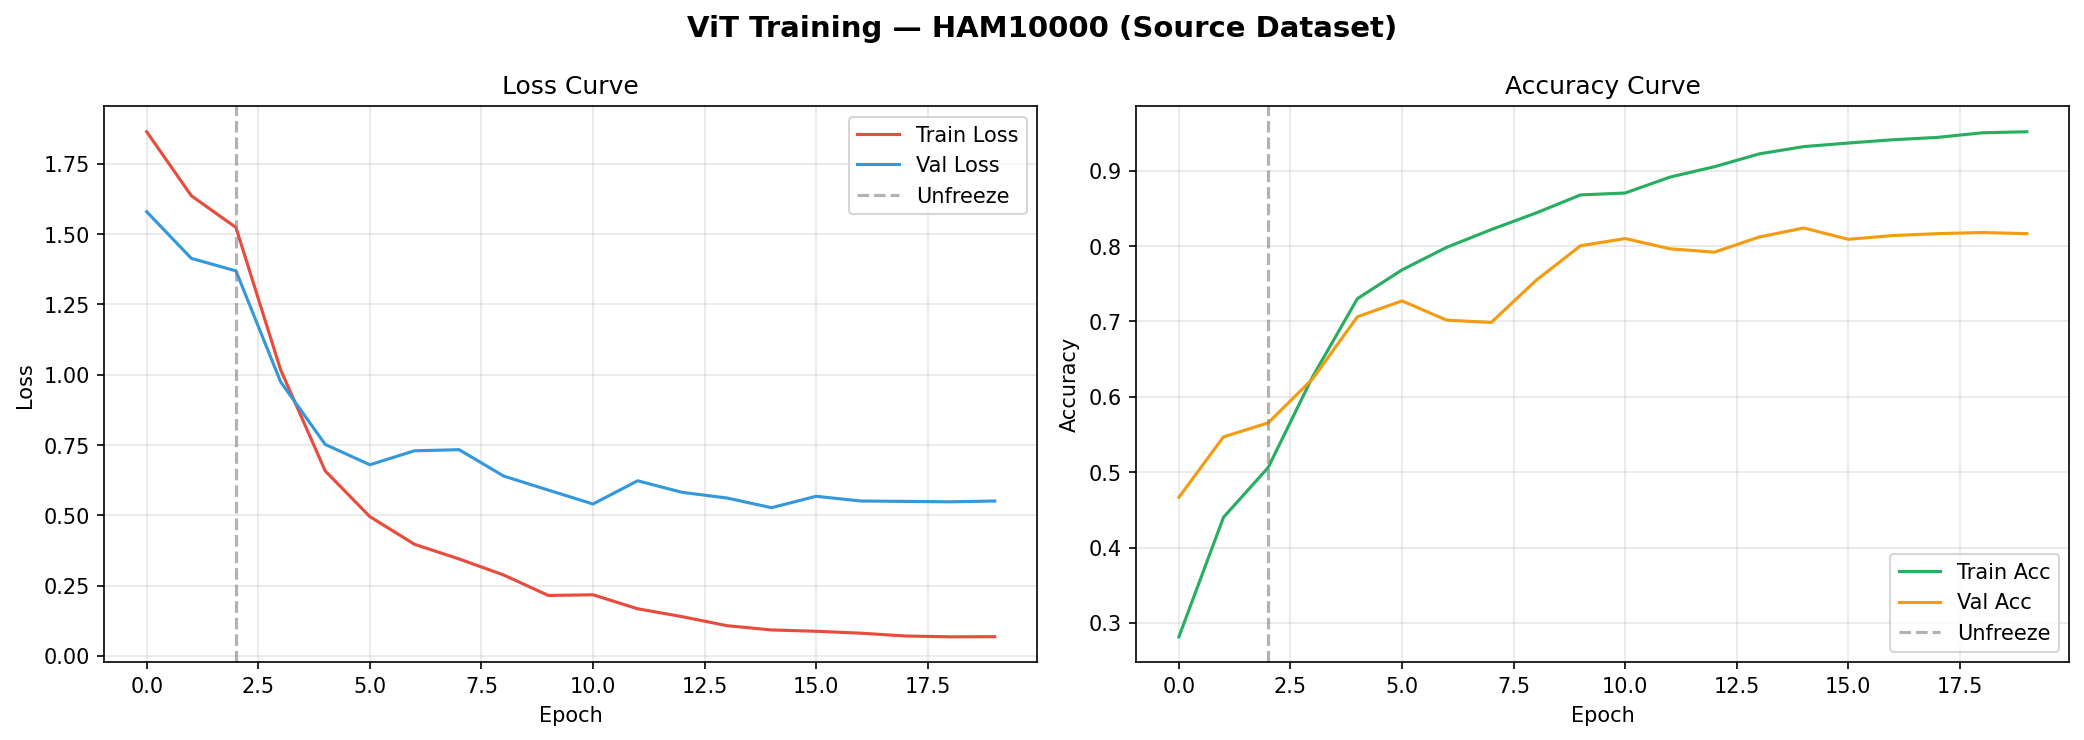

In [44]:
from IPython.display import Image, display

img_path = OUTPUT_DIR / 'vit_ham10000_training_curves.png'

display(Image(filename=img_path))